In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import MultipleLocator
import os
os.environ["PATH"] = "/opt/software-current/2023.06/x86_64/generic/software/texlive/20230313-GCC-12.3.0/bin/x86_64-linux:/Library/TeX/texbin:" + os.environ.get("PATH","")
from scipy.stats import gaussian_kde
from PIL import Image
import numpy as np

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ---------- LaTeX ----------
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # ---------- Font sizes ----------
    "font.size": 24,            # 全局默认字号
    "axes.labelsize": 24,       # 坐标轴标题
    "axes.titlesize": 24,       # 子图标题
    "xtick.labelsize": 24,      # x 轴刻度
    "ytick.labelsize": 24,      # y 轴刻度
    "legend.fontsize": 24,      # 图例字号
    "legend.title_fontsize": 24,

    # ---------- Axes ----------
    "axes.linewidth": 1.2,      # 坐标轴边框线宽
    "axes.unicode_minus": False,

    # ---------- Lines ----------
    "lines.linewidth": 2.0,
    "lines.markersize": 8,

    # ---------- Ticks ----------
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # ---------- Legend ----------
    "legend.frameon": False,    # 论文图通常不用边框
    "legend.handlelength": 1.8,
    "legend.handletextpad": 0.4,
    "legend.borderpad": 0.3,
    "legend.labelspacing": 0.3,

    # ---------- Figure ----------
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # ---------- PDF/PS ----------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [3]:

def plot_kde(
    ax, x, v, zmax=0.015, show_xlabel=False, show_ylabel=False,
    title=None, bw_method=None
):
    L = 4 * np.pi

    # periodic extension in x
    x_ext = np.concatenate([x - L, x, x + L])
    v_ext = np.concatenate([v, v, v])

    values_ext = np.vstack([x_ext, v_ext])
    kde = gaussian_kde(values_ext, bw_method=bw_method)

    xmin, xmax = 0, 4 * np.pi
    vmin, vmax = -2, 2

    X, V = np.meshgrid(
        np.linspace(xmin, xmax, 250),
        np.linspace(vmin, vmax, 250)
    )

    Z = kde(np.vstack([X.ravel(), V.ravel()])).reshape(X.shape)

    levels = np.linspace(0, zmax, 60)
    im = ax.contourf(
        X, V, Z,
        levels=levels,
        extend="max",
        cmap="plasma"
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(vmin, vmax)

    # ticks
    ax.set_xticks([0, np.pi, 2*np.pi, 3*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$", r"$3\pi$"])
    ax.set_yticks([-2, -1, 0, 1, 2])

    ax.tick_params(direction="in", length=6, width=1.2, top=True, right=True)

    if show_xlabel:
        ax.set_xlabel(r"$x$")
    else:
        ax.tick_params(labelbottom=False)

    if show_ylabel:
        ax.set_ylabel(r"$v$")
    else:
        ax.tick_params(labelleft=False)

    # if title is not None:
    #     ax.set_title(title, pad=8)

    return im


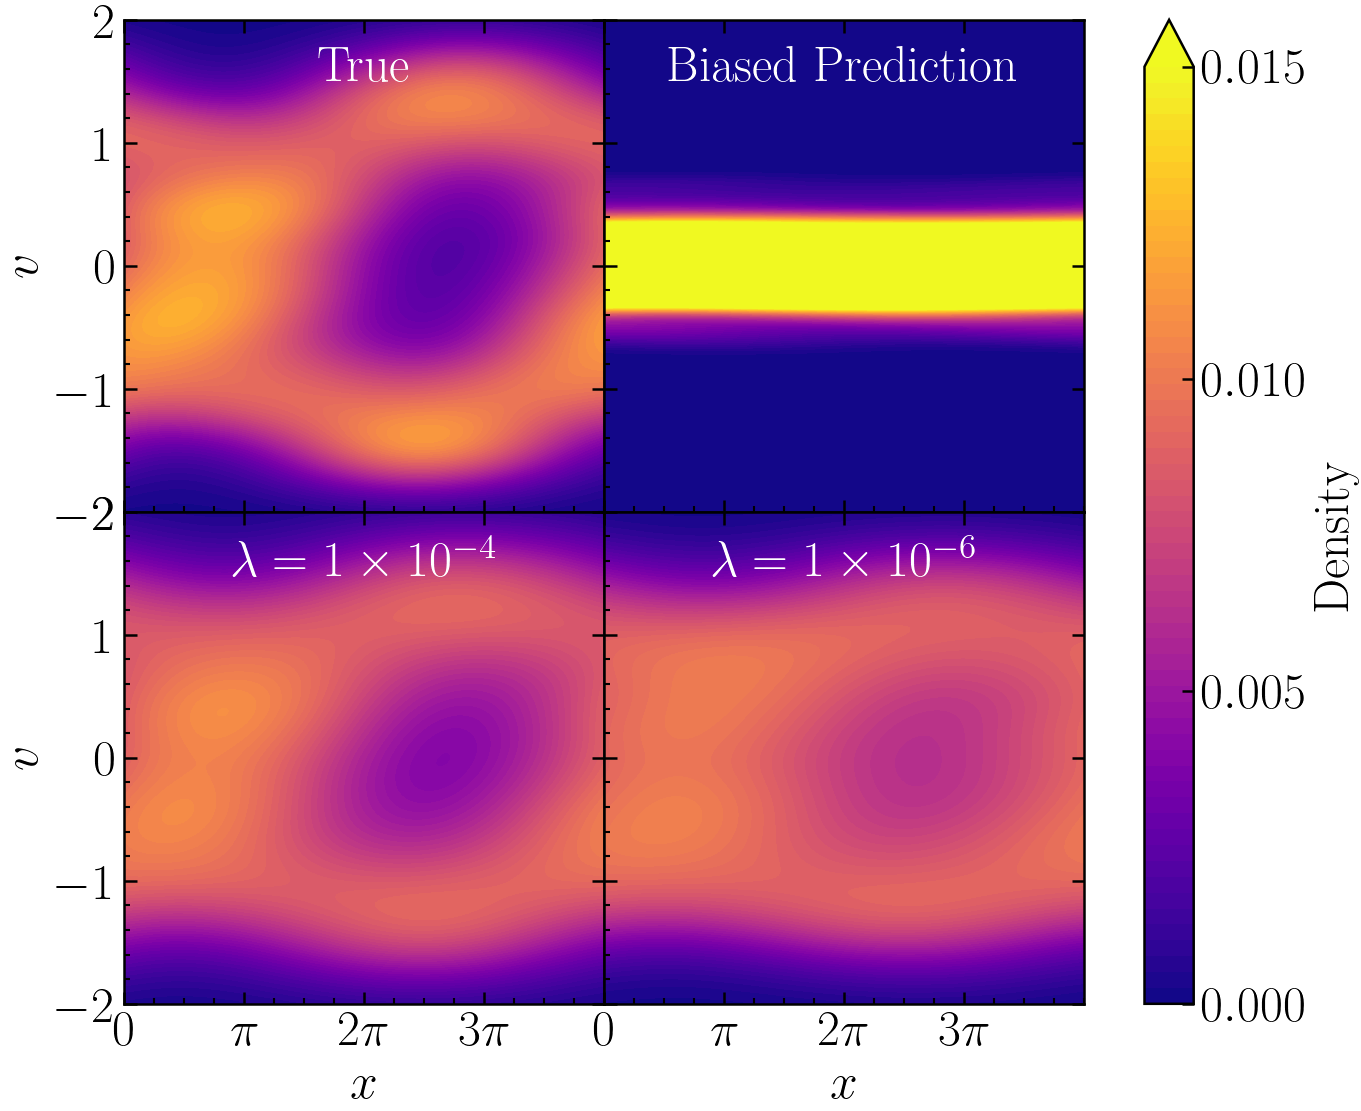

In [9]:
fig, ax = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)

zmax = 0.015
step =  1000
# --- True ---
data = np.load("./simulation/data/mv_sim_seed0.npz")
im = plot_kde(
    ax[0, 0],
    data["x_paths"][step, ::10],
    data["v_paths"][step, ::10],
    zmax=zmax,
    show_xlabel=False,
    show_ylabel=True,
    title="True"
)

# --- Biased prediction ---
data = np.load("./assimilation/data_lambda_0/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[0, 1],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=False,
    show_ylabel=False,
    title="Biased Prediction"
)

# --- lambda = 1e-4 ---
data = np.load("./assimilation/data_lambda_1e_4/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[1, 0],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=True,
    show_ylabel=True,
    title=None
)

# --- lambda = 1e-6 ---
data = np.load("./assimilation/data_lambda_1e_6/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[1, 1],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=True,
    show_ylabel=False,
    title=None
)

# --- top row ---
ax[0, 0].text(
    0.5, 0.9, "True",
    transform=ax[0, 0].transAxes,
    ha="center", va="center",
    color="white"
)

ax[0, 1].text(
    0.5, 0.9, "Biased Prediction",
    transform=ax[0, 1].transAxes,
    ha="center", va="center",
    color="white"
)

# --- bottom row ---
ax[1, 0].text(
    0.5, 0.9, r"$\lambda = 1 \times 10^{-4}$",
    transform=ax[1, 0].transAxes,
    ha="center", va="center",
    color="white"
)

ax[1, 1].text(
    0.5, 0.9, r"$\lambda = 1 \times 10^{-6}$",
    transform=ax[1, 1].transAxes,
    ha="center", va="center",
    color="white"
)

# manual spacing is better than tight_layout here
fig.subplots_adjust(left=0.10, right=0.90, bottom=0.10, top=0.92)

# one shared colorbar
cbar = fig.colorbar(im, ax=ax,ticks=[ 0, 0.005,0.01,0.015])
cbar.ax.tick_params()
cbar.set_label("Density")

plt.savefig("two_stream_step_1000")

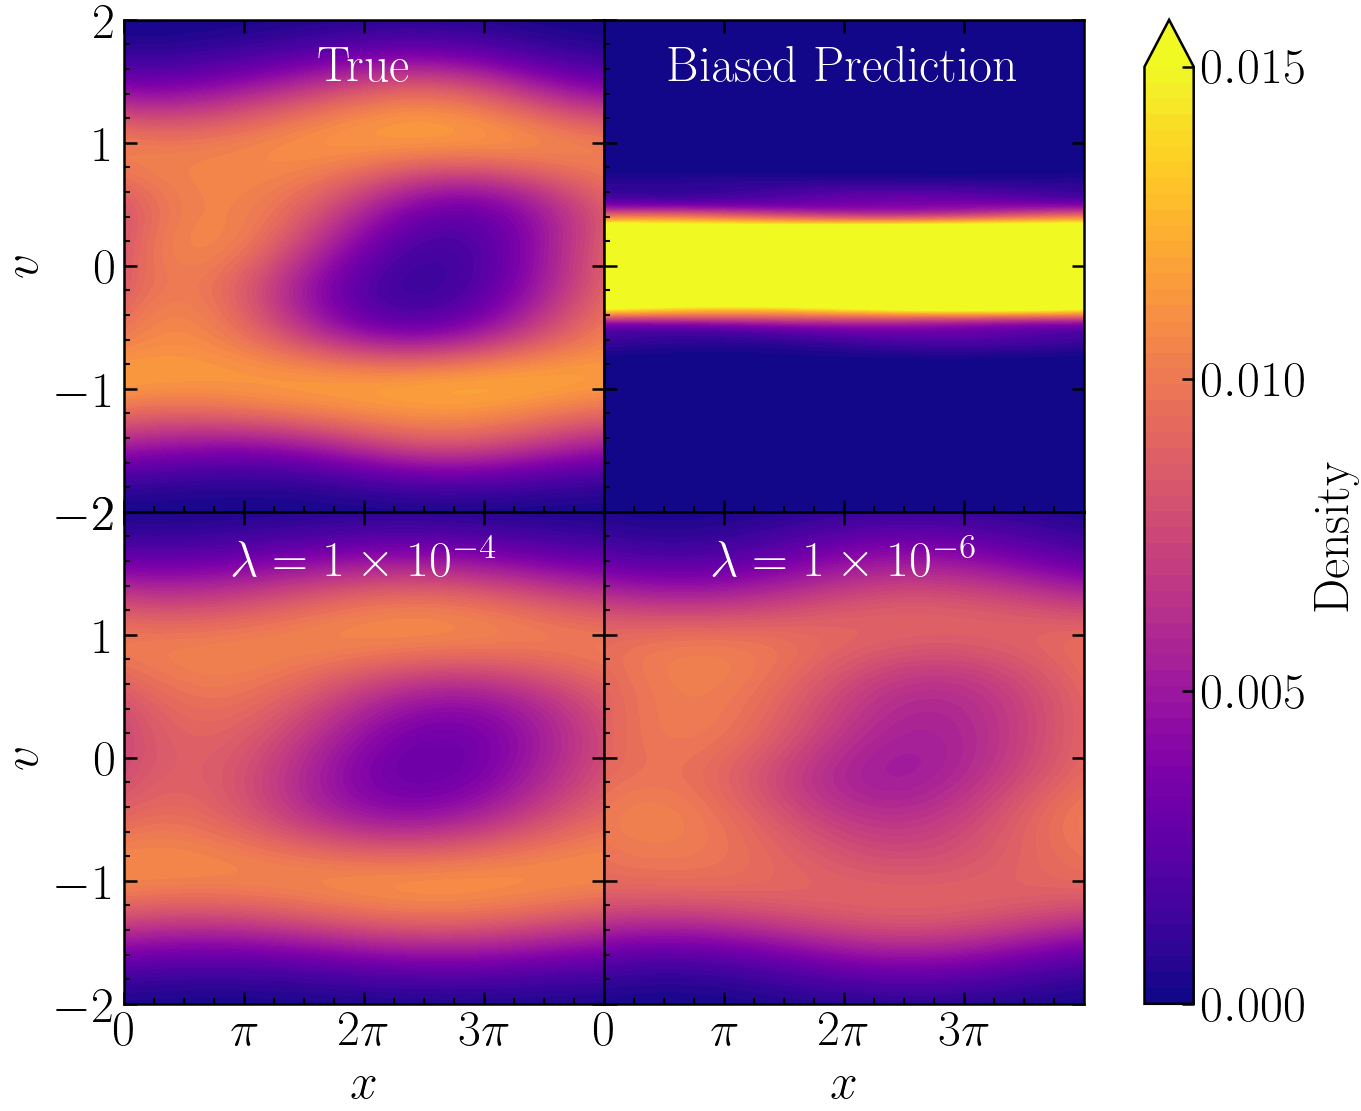

In [8]:
fig, ax = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)

zmax = 0.015
step =  2000
# --- True ---
data = np.load("./simulation/data/mv_sim_seed0.npz")
im = plot_kde(
    ax[0, 0],
    data["x_paths"][step, ::10],
    data["v_paths"][step, ::10],
    zmax=zmax,
    show_xlabel=False,
    show_ylabel=True,
    title="True"
)

# --- Biased prediction ---
data = np.load("./assimilation/data_lambda_0/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[0, 1],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=False,
    show_ylabel=False,
    title="Biased Prediction"
)

# --- lambda = 1e-4 ---
data = np.load("./assimilation/data_lambda_1e_4/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[1, 0],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=True,
    show_ylabel=True,
    title=None
)

# --- lambda = 1e-6 ---
data = np.load("./assimilation/data_lambda_1e_6/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[1, 1],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=True,
    show_ylabel=False,
    title=None
)

# --- top row ---
ax[0, 0].text(
    0.5, 0.9, "True",
    transform=ax[0, 0].transAxes,
    ha="center", va="center",
    color="white"
)

ax[0, 1].text(
    0.5, 0.9, "Biased Prediction",
    transform=ax[0, 1].transAxes,
    ha="center", va="center",
    color="white"
)

# --- bottom row ---
ax[1, 0].text(
    0.5, 0.9, r"$\lambda = 1 \times 10^{-4}$",
    transform=ax[1, 0].transAxes,
    ha="center", va="center",
    color="white"
)

ax[1, 1].text(
    0.5, 0.9, r"$\lambda = 1 \times 10^{-6}$",
    transform=ax[1, 1].transAxes,
    ha="center", va="center",
    color="white"
)

# manual spacing is better than tight_layout here
fig.subplots_adjust(left=0.10, right=0.90, bottom=0.10, top=0.92)

# one shared colorbar
cbar = fig.colorbar(im, ax=ax,ticks=[ 0, 0.005,0.01,0.015])
cbar.ax.tick_params()
cbar.set_label("Density")

plt.savefig("two_stream_step_2000")

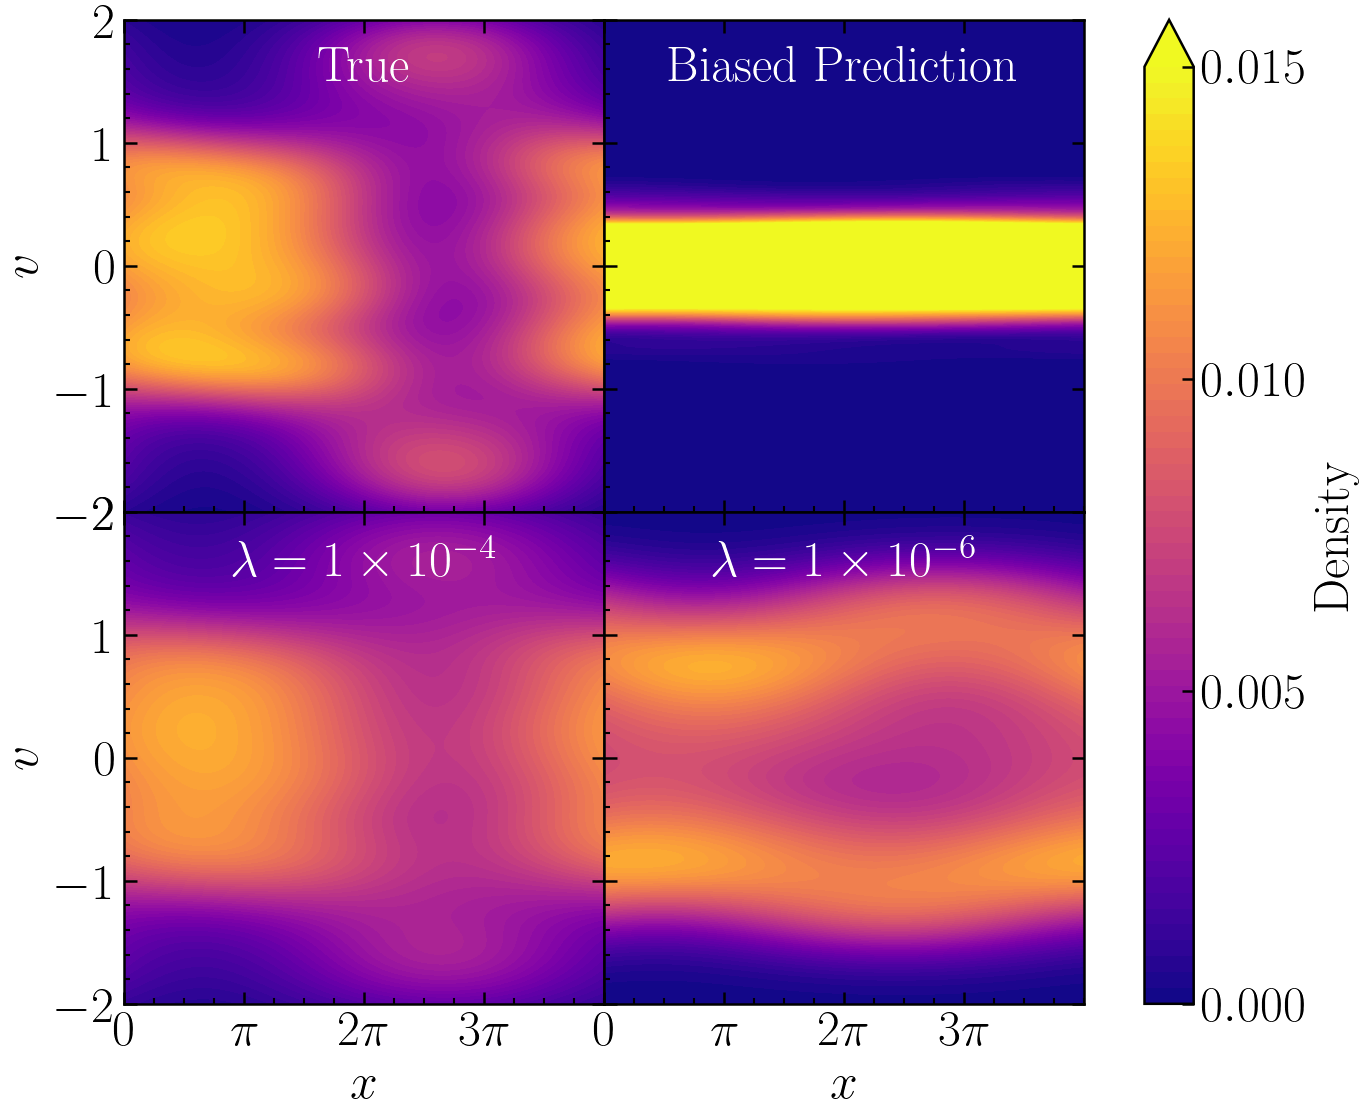

In [10]:
fig, ax = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)

zmax = 0.015
step =  500
# --- True ---
data = np.load("./simulation/data/mv_sim_seed0.npz")
im = plot_kde(
    ax[0, 0],
    data["x_paths"][step, ::10],
    data["v_paths"][step, ::10],
    zmax=zmax,
    show_xlabel=False,
    show_ylabel=True,
    title="True"
)

# --- Biased prediction ---
data = np.load("./assimilation/data_lambda_0/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[0, 1],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=False,
    show_ylabel=False,
    title="Biased Prediction"
)

# --- lambda = 1e-4 ---
data = np.load("./assimilation/data_lambda_1e_4/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[1, 0],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=True,
    show_ylabel=True,
    title=None
)

# --- lambda = 1e-6 ---
data = np.load("./assimilation/data_lambda_1e_6/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(
    ax[1, 1],
    data["x_est"][step, :],
    data["v_est"][step, :],
    zmax=zmax,
    show_xlabel=True,
    show_ylabel=False,
    title=None
)

# --- top row ---
ax[0, 0].text(
    0.5, 0.9, "True",
    transform=ax[0, 0].transAxes,
    ha="center", va="center",
    color="white"
)

ax[0, 1].text(
    0.5, 0.9, "Biased Prediction",
    transform=ax[0, 1].transAxes,
    ha="center", va="center",
    color="white"
)

# --- bottom row ---
ax[1, 0].text(
    0.5, 0.9, r"$\lambda = 1 \times 10^{-4}$",
    transform=ax[1, 0].transAxes,
    ha="center", va="center",
    color="white"
)

ax[1, 1].text(
    0.5, 0.9, r"$\lambda = 1 \times 10^{-6}$",
    transform=ax[1, 1].transAxes,
    ha="center", va="center",
    color="white"
)

# manual spacing is better than tight_layout here
fig.subplots_adjust(left=0.10, right=0.90, bottom=0.10, top=0.92)

# one shared colorbar
cbar = fig.colorbar(im, ax=ax,ticks=[ 0, 0.005,0.01,0.015])
cbar.ax.tick_params()
cbar.set_label("Density")

plt.savefig("two_stream_step_500")